# K-Means Clustering

# I. Preparation Dataset

## A. Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## B. Import Dataset

In [1074]:
dataset = pd.read_csv("Iris.csv")
dataset

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


## C. Inspeksi Ukuran Dataset

In [1075]:
row, column = dataset.shape
print(f"Ukuran dataset adalah {column} x {row}")

Ukuran dataset adalah 6 x 150


## D. Identifikasi Daftar Variabel

In [1076]:
dataset.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

## E. Inspeksi Tipe Data Kolom

In [1077]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


karena terdapat kolom yang bersifat objek, maka kita harus encode terlebih dahulu

## F. Inspeksi Data Kotor (NaN, Duplikat)

In [1078]:
print("-------------------------------------------------")
print("Jumlah data yang duplikat: ", dataset.duplicated().sum())
print("-------------------------------------------------")
print(f"Jumlah data yang NaN: \n{dataset.isna().sum()}")
print("-------------------------------------------------")

-------------------------------------------------
Jumlah data yang duplikat:  0
-------------------------------------------------
Jumlah data yang NaN: 
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
-------------------------------------------------


## G. Data Cleaning

### 1. Encode Variabel

In [1079]:
dataset["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [1080]:
dataset["Species"] = pd.factorize(dataset["Species"])[0]
dataset["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

### 2. Inspeksi Ulang Dataset

In [1081]:
print("-------------------------------------------------")
print("Jumlah data yang duplikat: ", dataset.duplicated().sum())
print("-------------------------------------------------")
print(f"Jumlah data yang NaN: \n{dataset.isna().sum()}")
print("-------------------------------------------------")
dataset.info()
print("-------------------------------------------------")

-------------------------------------------------
Jumlah data yang duplikat:  0
-------------------------------------------------
Jumlah data yang NaN: 
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
-------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 7.2 KB
-------------------------------------------------


# II. Exploratory Data Analysis

## A. Inspeksi Outlier

### 1. Seluruh Dataset

<Axes: >

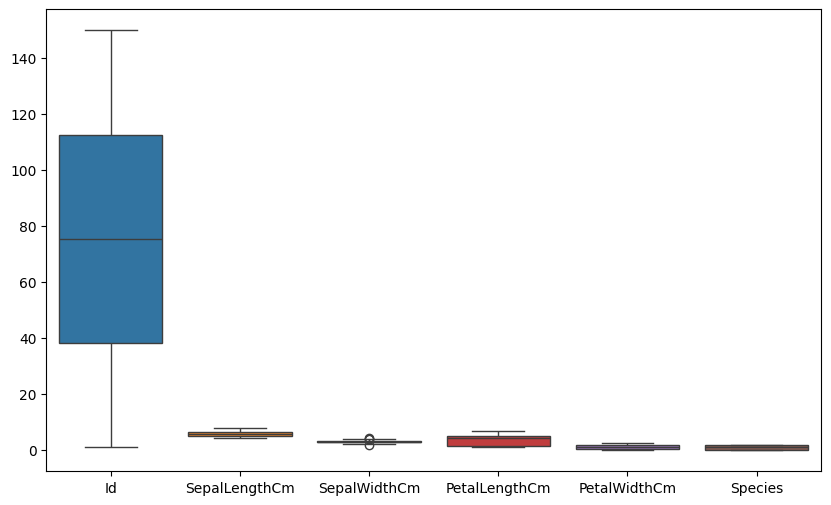

In [1082]:
plt.figure(figsize=(10,6))
sns.boxplot(dataset)

### 2. Kolom SepalWidthCm

<Axes: ylabel='SepalWidthCm'>

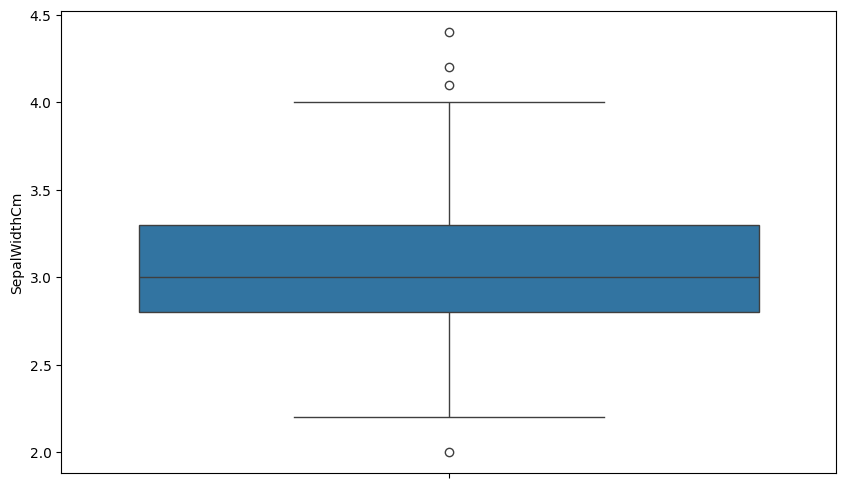

In [1083]:
plt.figure(figsize=(10,6))
sns.boxplot(dataset["SepalWidthCm"])

Karena letak outlier tidak terlalu jauh dari rata-rata, maka kita tidak perlu menangani outlier.

## B. Inspeksi Korelasi

<Axes: >

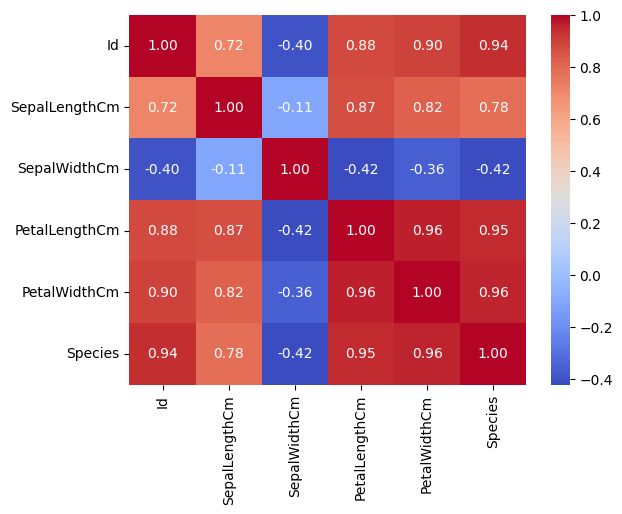

In [1084]:
sns.heatmap(dataset.corr(), cmap="coolwarm", fmt=".2f", annot=True)

## C. Inspeksi Distribusi Data

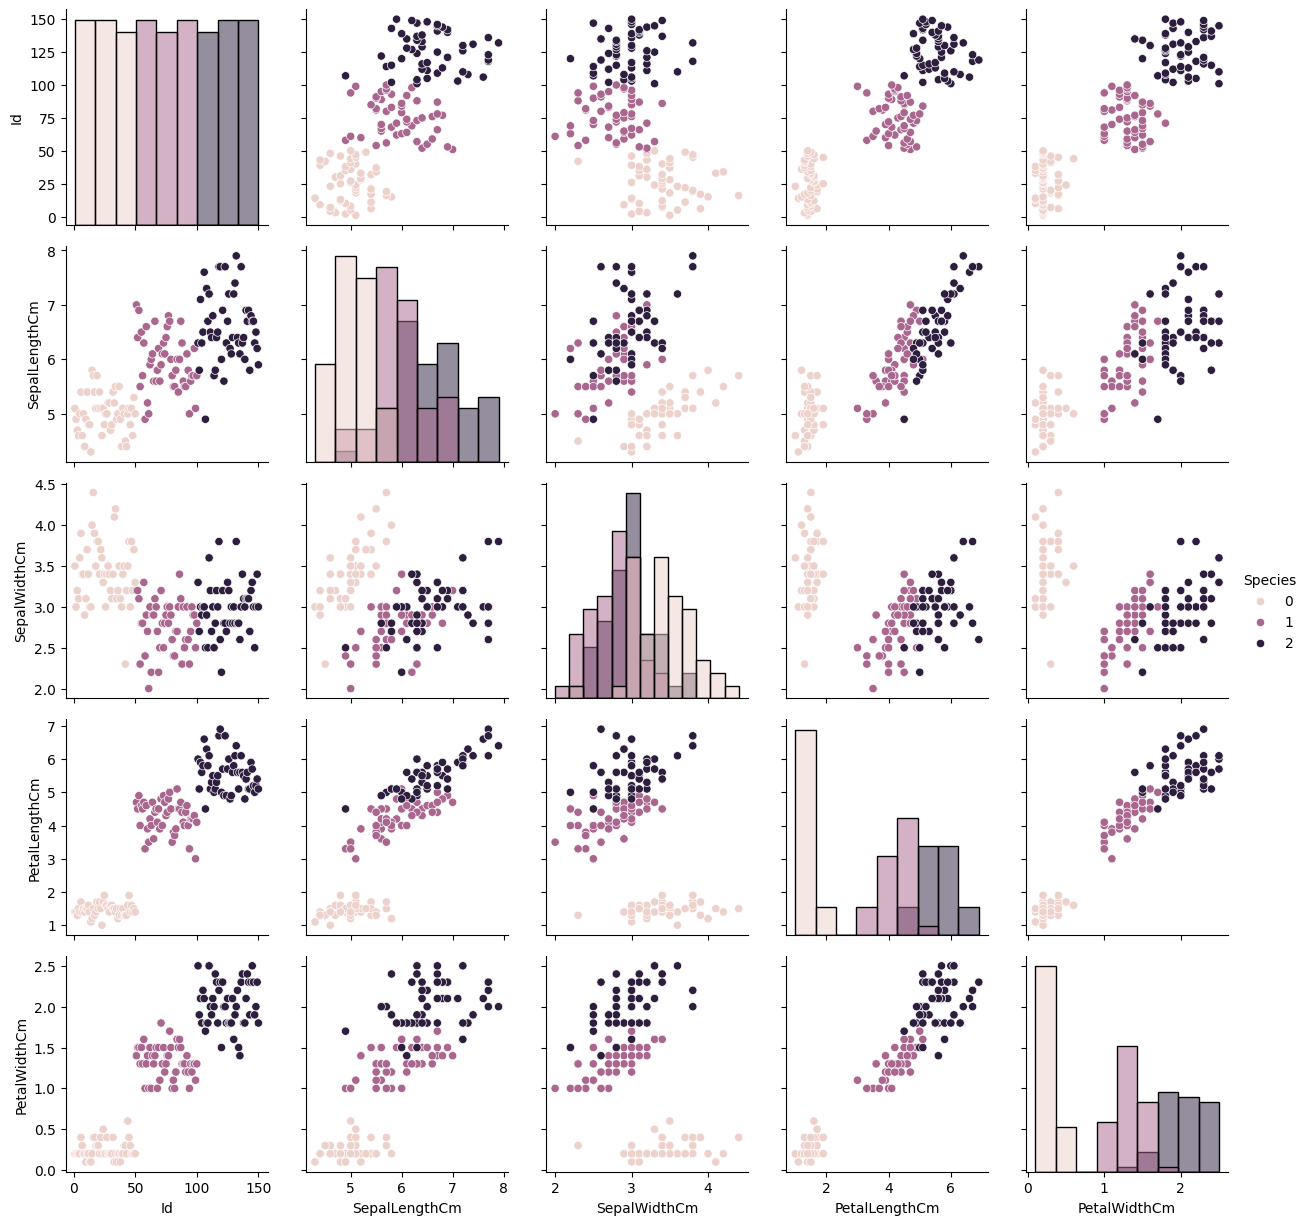

In [1085]:
g = sns.PairGrid(dataset, hue="Species", diag_sharey=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.show()

## D. Deklarasi Fitur

In [1086]:
# X = dataset[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]] 
X = dataset[["PetalLengthCm","PetalWidthCm"]]

## E. Feature Scaling

In [1087]:
X_norm = (X - X.min()) / (X.max() - X.min())

<Axes: >

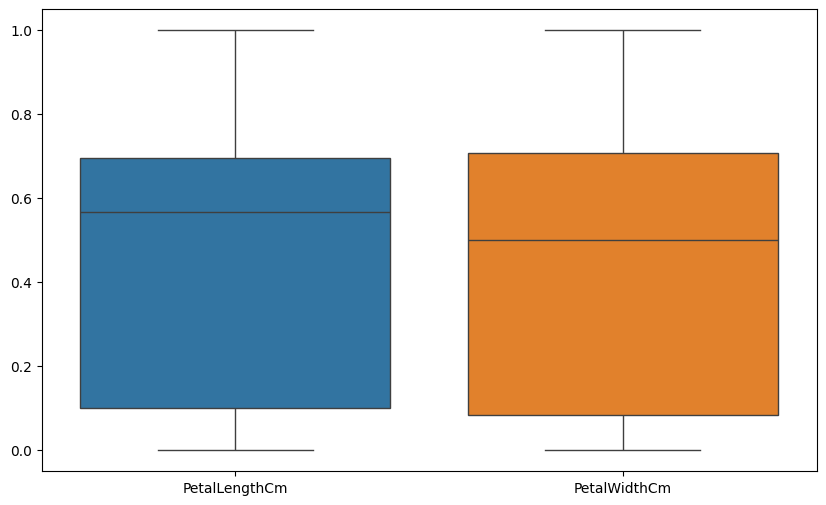

In [1088]:
plt.figure(figsize=(10,6))
sns.boxplot(X_norm)

# III. Modeling

## A. Fungsi PCA

In [1089]:
def pca(X, n_components=2):
    X_centered = X - np.mean(X, axis=0)
    convariance_matrix = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eig(convariance_matrix)

    sorted_indices = np.argsort(eigenvalues)[::1]
    top_eigenvectors = eigenvectors[:, sorted_indices[:n_components]]
    X_pca = np.dot(X_centered, top_eigenvectors)

    return X_pca

X_pca = pca(X_norm)

## B. Randomize dan Splitting Data

In [1090]:
def split_data(X, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    random_index = np.random.permutation(len(X))
    index_training = int(len(X) * training_size)

    X_train = X[random_index[:index_training]]
    X_test = X[random_index[index_training:]]

    return X_train, X_test

X_train_pca, X_test_pca = split_data(X_pca)

## C. Model K-Means

In [1091]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [1092]:
def kmeans(X, k, max_iters=1000):
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        labels = np.array([np.argmin([euclidean_distance(x, c) for c in centroids]) for x in X])
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        if np.all(centroids == new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

## D. Elbow Method

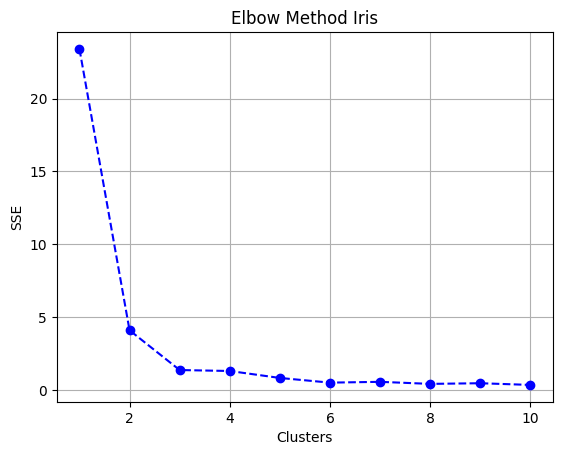

In [1093]:
def calculate_sse(X, labels, centroids):
    sse = 0

    for i,centroids in enumerate(centroids):
        centroid_distribution = X[labels == i]
        sse += np.sum((centroid_distribution - centroids) ** 2)
    return sse

def elbow_method(X, max_k,):
    sse_value = []

    for k in range(1, 1 + max_k):
        labels, centroids = kmeans(X, k)
        total_sse = calculate_sse(X, labels, centroids)
        sse_value.append(total_sse)
    
    return sse_value

max_k = 10
sikut = elbow_method(X_train_pca, max_k)

plt.title("Elbow Method Iris")
plt.plot(range(1, 1 + max_k), sikut, marker="o", linestyle="--", color="b")
plt.xlabel("Clusters")
plt.ylabel("SSE")
plt.grid()
plt.show()

## E. Hasil Pengelompokan

In [1094]:
k = 3
train_labels, train_centroids = kmeans(X_train_pca, k)
test_labels, test_centroids = kmeans(X_test_pca, k)

In [1095]:
all_labels = np.concatenate([train_labels, test_labels])
dataset["Cluster"] = all_labels
dataset

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,0,2
1,2,4.9,3.0,1.4,0.2,0,0
2,3,4.7,3.2,1.3,0.2,0,1
3,4,4.6,3.1,1.5,0.2,0,2
4,5,5.0,3.6,1.4,0.2,0,2
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2,2
146,147,6.3,2.5,5.0,1.9,2,2
147,148,6.5,3.0,5.2,2.0,2,0
148,149,6.2,3.4,5.4,2.3,2,2


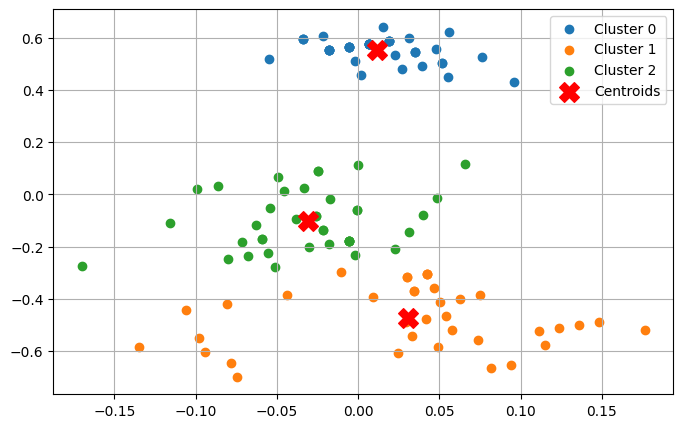

In [1096]:
plt.figure(figsize=(8, 5))

for cluster in range(k):
    cluster_points = X_train_pca[train_labels == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster}")

plt.scatter(train_centroids[:, 0], train_centroids[:, 1], color="red", marker="X", s=200, label="Centroids")
plt.legend()
plt.grid()
plt.show()

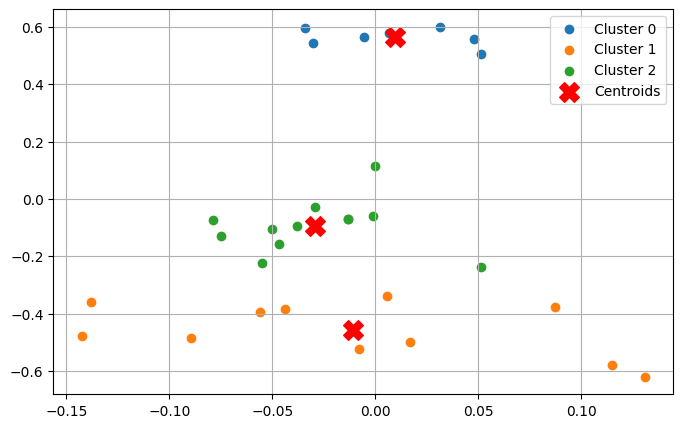

In [1097]:
plt.figure(figsize=(8, 5))

for cluster in range(k):
    cluster_points = X_test_pca[test_labels == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster}")

plt.scatter(test_centroids[:, 0], test_centroids[:, 1], color="red", marker="X", s=200, label="Centroids")
plt.legend()
plt.grid()
plt.show()

# IV. Evaluation

In [1098]:
def evaluation(X, labels, centroids):
    inertia = 0
    for i, c in enumerate(centroids):
        cluster_points = X[labels == i]
        inertia += np.sum((cluster_points - c) ** 2)

    silhouette_scores = []

    for i, x in enumerate(X):
        current_cluster = labels[i]

        in_cluster_points = X[labels == current_cluster]
        out_cluster_points = X[labels != current_cluster]

        a_i = np.mean([euclidean_distance(x, p) for p in in_cluster_points if not np.array_equal(x, p)])
        b_i = np.mean([euclidean_distance(x, p) for p in out_cluster_points])
        s_i = (b_i - a_i) / max(a_i, b_i)

        silhouette_scores.append(s_i)
        silhouette = np.mean(silhouette_scores)

    return inertia, silhouette

inertia, silhouette = evaluation(X_test_pca, test_labels, test_centroids)

In [1099]:
print("-----------------------------------------")
print(f"Hasil Inertia: {inertia}")
print("-----------------------------------------")
print("-----------------------------------------")
print(f"Hasil Silhouette Score: {silhouette}")
print("-----------------------------------------")

-----------------------------------------
Hasil Inertia: 0.29945150823221045
-----------------------------------------
-----------------------------------------
Hasil Silhouette Score: 0.7828509725323414
-----------------------------------------


Evaluasi yang didapatkan:
*   Jika fitur = "SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm" menghasilkan hasil Inertia yang keccil yaitu 0.111, namun menghasilkan silhouette yang kurang optimal yaitu 0.563
*   Jika fitur = "PetalLengthCm", "PetalWidthCm" menghasilkan inertia yang cuktup rendah yaitu 0.299 dan silhouette score yang sangat baik yaitu  0.782

Kesimpulan yang dapat ditarik dari model clustering terhadap dataset Iris adalah:
*   Dataset kurang besar sehingga semua fitur belum terpakai secara maksimal, bisa dilihat dari perbedaan hasil evaluasi ketika memakai semua fitur dan hasil evaluasi ketika memakai fitur yang memiliki korelasi kuat terhadap Species.
*   Overall model sudah cukup optimal untuk dataset iris